In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

__一、画AIA图像+ AIA GOES曲线__

读取GOES数据

In [2]:
import netCDF4 as nc
ff=nc.Dataset(r'D:\Learning\PHD1st\magnetic_reconnecion\data\GOES\sci_exis-l1b-sfxr_g16_d20240618_v0-0-1.nc' )
print(ff.variables.keys()) 

dict_keys(['irradiance_xrsa1', 'irradiance_xrsa2', 'primary_xrsa', 'irradiance_xrsb1', 'irradiance_xrsb2', 'primary_xrsb', 'xrs_ratio', 'corrected_current_xrsa_1', 'corrected_current_xrsa_2', 'corrected_current_xrsa_3', 'corrected_current_xrsa_4', 'corrected_current_xrsb_1', 'corrected_current_xrsb_2', 'corrected_current_xrsb_3', 'corrected_current_xrsb_4', 'dispersion_angle', 'crossdispersion_angle', 'sc_power_side', 'exis_flight_model', 'exis_configuration_id', 'xrs_runctrlmd', 'integration_time', 'exs_sl_pwr_ena', 'asic1_temperature', 'asic2_temperature', 'invalid_flags', 'xrs_det_chg', 'xrs_mode', 'sps_obs_time', 'sps_int_time', 'sps_temperature', 'sps_det_chg', 'num_angle_pairs', 'yaw_flip_flag', 'au_factor', 'quality_flags', 'time', 'packet_count', 'fov_unknown', 'fov_eclipse', 'fov_lunar_transit', 'fov_planet_transit', 'fov_off_point', 'quaternion_Q0', 'quaternion_Q1', 'quaternion_Q2', 'quaternion_Q3', 'ecef_X', 'ecef_Y', 'ecef_Z', 'solar_array_current', 'SC_eclipse_flag', 'prod

In [3]:
#这里dir1是pre_131.sav的目录对应0-31，dir2是131.sav的目录对应32-132，exptime是长148的观测时间
def aia_intensity_curve(dir1,dir2,exptime,wavelenth):
    from scipy.io import readsav
    #这部分先把数据读入进来
    matrices=[]
    data1=readsav(dir1)
    matrix_struct=data1['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    matrices=matrices[69:]
    data2=readsav(dir2)
    matrix_struct=data2['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    #计算平均强度
    intensity=np.zeros(133)
    for i in range(133):
        intensity[i]=np.average(matrices[i])
    #这里去掉曝光时间不一致的点，131和193单独处理
    if wavelenth=='131' or '193':
        threshold=2.90 if wavelenth=='131' else 1.99
        #print(threshold)
        intensity[exptime[:133]<threshold]=np.nan
        #把去掉的点用插值函数补上
        x=np.arange(133)
        valid_x=x[~np.isnan(intensity)]
        valid_intensity=intensity[~np.isnan(intensity)]
        f=interp1d(valid_x,valid_intensity,kind='linear')
        intensity[np.isnan(intensity)]=f(x[np.isnan(intensity)])
    #归一化
    intensity=(intensity-np.min(intensity))/(np.max(intensity)-np.min(intensity))
    return intensity

AIA强度数据

In [4]:
intensity=np.zeros((7,133))
name_list=['.94','131','171','193','211','304','335']

for i in range(7):
    file_list=glob.glob(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'\*.fits')
    exptime=np.zeros(len(file_list))
    for j in range(len(file_list)):
        rsm=fits.open(file_list[j])
        exptime[j]=rsm[1].header['EXPTIME']

    dir1=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\pre_'+name_list[i]+'.sav'
    dir2=r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'.sav'
    intensity[i,:]=aia_intensity_curve(dir1,dir2,exptime[:133],name_list[i])
    #print(exptime[:133])

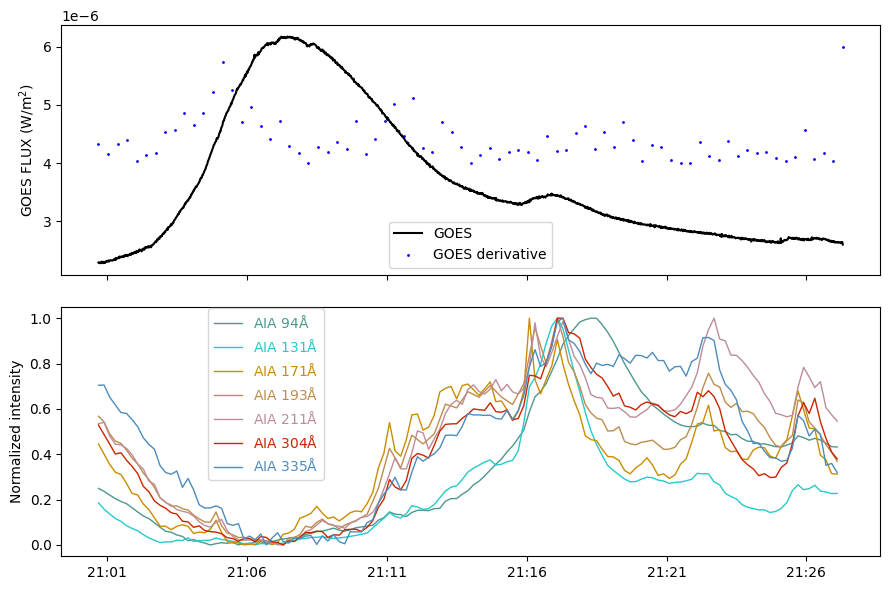

In [63]:
from scipy.interpolate import splprep, splev
from scipy.ndimage import zoom
corr_x=np.zeros(6)
#第一个时刻对应21：00：42，最后一个时刻对应21：27：06
for i in range(len(corr_x)):
    corr_x[i]=(i*300+18)/12
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,6), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
#y为GOES值
goes_x=np.linspace(0,133,1585)
goes_y=ff.variables['irradiance_xrsb1'][75642:75642+1585]
#求导，缩并
dy_dx=np.gradient(goes_y,goes_x)
dy_dx_reduced=zoom(dy_dx,0.05)

ax1.plot(goes_x,goes_y,color='black',label='GOES')
der_goes=abs(dy_dx_reduced)
der_goes2=(der_goes-np.min(der_goes))/(np.max(der_goes)-np.min(der_goes))
ax1.scatter(np.linspace(0,133,len(dy_dx_reduced)),(der_goes2+2)*1e-6*2,color='blue',s=1,label='GOES derivative')
ax1.set_ylabel('GOES FLUX (W/m$^2$)')

handles1, labels1 = ax1.get_legend_handles_labels()

ax1.legend(handles1, labels1, loc='best')

name_list=['AIA 94$\mathrm{\AA}$','AIA 131$\mathrm{\AA}$',
           'AIA 171$\mathrm{\AA}$','AIA 193$\mathrm{\AA}$',
           'AIA 211$\mathrm{\AA}$','AIA 304$\mathrm{\AA}$','AIA 335$\mathrm{\AA}$']
lines=[]
linstyle=['-','-']

color=[]
color_list=['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335']
for i in range(7):
    cmap=plt.get_cmap(color_list[i])
    middle_color=cmap(0.55)
    color.append(middle_color)
    
#color=['green','orange','deepskyblue','blue','red','purple','brown']

for i in range(7):
    line,=ax2.plot(intensity[i,:],color=color[i],label=name_list[i],linewidth=1,linestyle=linstyle[i%2])
    lines.append(line)
legend=ax2.legend(loc='center', bbox_to_anchor=(0.25, 0.65))
for text,line in zip(legend.get_texts(),lines):
    #print(line.get_color())
    text.set_color(line.get_color())
ax2.set_ylabel('Normalized intensity')
ax2.set_xticks(ticks=corr_x,labels=['21:01','21:06','21:11','21:16','21:21','21:26'])
plt.tight_layout()
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\intensity_curve.pdf',format='pdf')

AIA图像数据

In [5]:
map1=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210908Z.131.image_lev1.fits')
map2=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211344Z.131.image_lev1.fits')
map3=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211632Z.131.image_lev1.fits')
map4=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211820Z.131.image_lev1.fits')
map5=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212232Z.131.image_lev1.fits')
map6=sunpy.map.Map(r'D:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\171\aia.lev1_euv_12s.2024-06-18T211822Z.171.image_lev1.fits')

Text(0.02, 0.93, '(a)            AIA131 21:07:08')

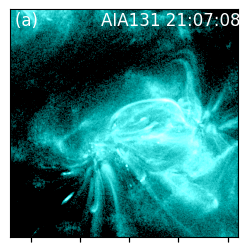

In [120]:
fig=plt.figure(figsize=(9,6))
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
gs=gridspec.GridSpec(6,9,wspace=0.1,hspace=0.05)

smap1=map5.submap(bottom_left,top_right=top_right)
ax1=fig.add_subplot(gs[0:3,0:3],projection=smap1)
ax1.set_xlabel('X(arcsecs)')
ax1.set_ylabel('Y(arcsecs)')
ax1.tick_params(axis='x',which='both',bottom=True,top=False,labeltop=False)
ax1.tick_params(axis='y',right=False,labelright=False)
norm=smap1.plot_settings['norm']
norm.vmin,norm.vmax=np.percentile(smap1.data,[20,99.9999])
im1=ax1.imshow(smap1.data,norm=norm,cmap=smap1.plot_settings['cmap'],origin='lower')
ax1.text(0.02,0.93,'(a)            AIA131 21:07:08',color='white',transform=ax1.transAxes,fontsize=12)
#cbar=fig.colorbar(im1,ax=ax1)

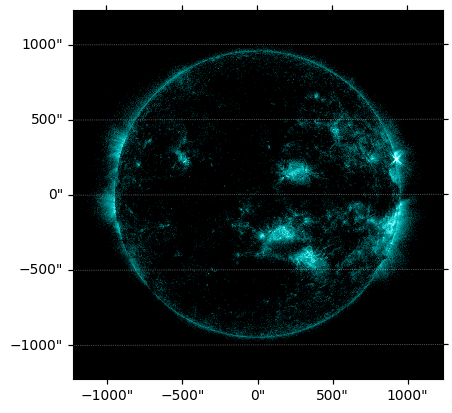

In [147]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(projection=map1)
map1.plot(axes=ax)

# 去掉 xlabel 和 ylabel
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.coords[0].grid(draw_grid=False)
ax.coords[1].grid(draw_grid=False)

Text(0.02, 0.93, '(f)    AIA 171  21:18:21 UT')

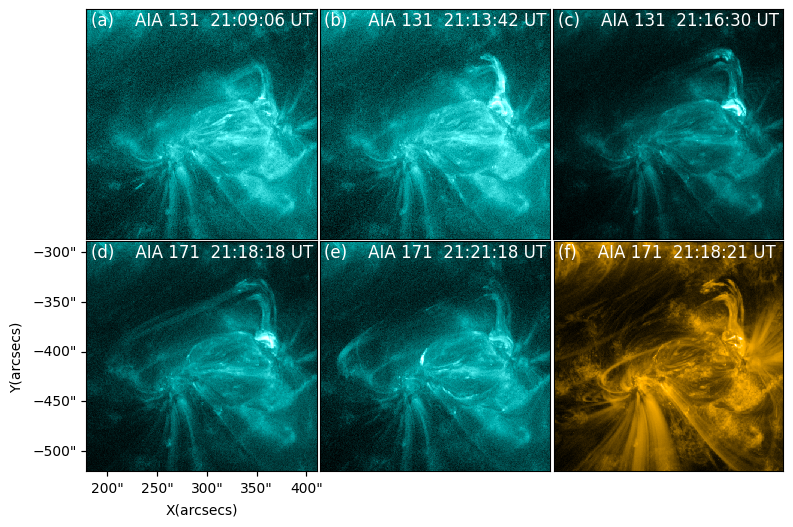

In [199]:
fig=plt.figure(figsize=(9,6))

bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
gs=gridspec.GridSpec(2,3,wspace=0.01,hspace=0.012)

map_all=[map1,map2,map3,map4,map5,map6]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

ax_all=[]
for i in range(6):
    ax=fig.add_subplot(gs[i],projection=smap_all[i])
    ax_all.append(ax)
    smap_all[i].plot(axes=ax)
    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第四张图加X Y轴
    if i == 3:   # 左下角
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X(arcsecs)',labelpad=1.1)
        ax.set_ylabel('Y(arcsecs)',labelpad=1.1)
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)       
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

ax_all[0].text(0.02,0.93,'(a)    AIA 131  21:09:06 UT',color='white',transform=ax_all[0].transAxes,fontsize=12)
ax_all[1].text(0.02,0.93,'(b)    AIA 131  21:13:42 UT',color='white',transform=ax_all[1].transAxes,fontsize=12)
ax_all[2].text(0.02,0.93,'(c)    AIA 131  21:16:30 UT',color='white',transform=ax_all[2].transAxes,fontsize=12)
ax_all[3].text(0.02,0.93,'(d)    AIA 171  21:18:18 UT',color='white',transform=ax_all[3].transAxes,fontsize=12)
ax_all[4].text(0.02,0.93,'(e)    AIA 171  21:21:18 UT',color='white',transform=ax_all[4].transAxes,fontsize=12)
ax_all[5].text(0.02,0.93,'(f)    AIA 171  21:18:21 UT',color='white',transform=ax_all[5].transAxes,fontsize=12)


C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:15: RuntimeWarning: divide by zero encountered in log10
  ax1.imshow(np.log10(smap1.data),cmap=smap1.plot_settings['cmap'],origin='lower')
C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:15: RuntimeWarning: invalid value encountered in log10
  ax1.imshow(np.log10(smap1.data),cmap=smap1.plot_settings['cmap'],origin='lower')
C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:20: RuntimeWarning: divide by zero encountered in log10
  ax2.imshow(np.log10(smap2.data),cmap=smap2.plot_settings['cmap'],origin='lower')
C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:20: RuntimeWarning: invalid value encountered in log10
  ax2.imshow(np.log10(smap2.data),cmap=smap2.plot_settings['cmap'],origin='lower')
C:\Users\19671\AppData\Local\Temp\ipykernel_15932\816855456.py:25: RuntimeWarning: divide by zero encountered in log10
  ax3.imshow(np.log10(smap3.data),cmap=smap3.plot_settings['cmap'],origin='

Text(0.2, 0.93, '(f) AIA171 21:07:08')

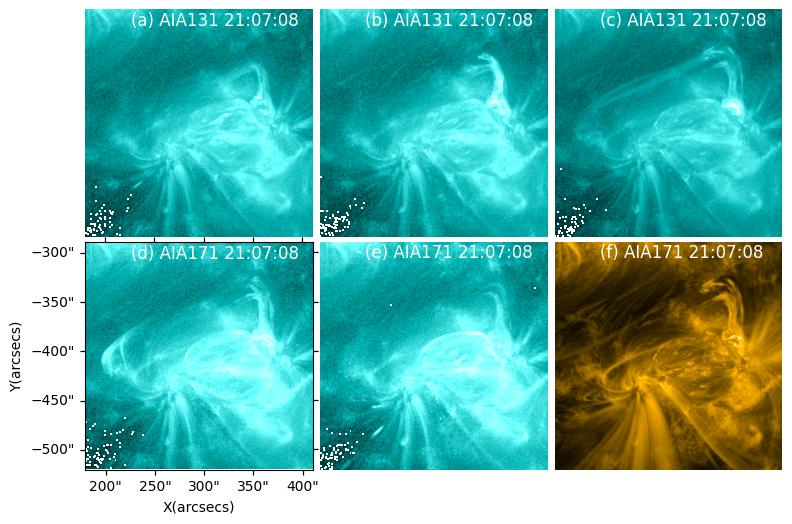

In [93]:
fig=plt.figure(figsize=(9,6))
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
gs=gridspec.GridSpec(6,9,wspace=0.1,hspace=0.05)

smap1=map1.submap(bottom_left,top_right=top_right)
smap2=map2.submap(bottom_left,top_right=top_right)
smap3=map3.submap(bottom_left,top_right=top_right)
smap4=map4.submap(bottom_left,top_right=top_right)
smap5=map5.submap(bottom_left,top_right=top_right)
smap6=map6.submap(bottom_left,top_right=top_right)

ax1=fig.add_subplot(gs[0:3,0:3],projection=smap1)
ax1.set_axis_off()
ax1.imshow(np.log10(smap1.data),cmap=smap1.plot_settings['cmap'],origin='lower')
ax1.text(0.2,0.93,'(a) AIA131 21:07:08',color='white',transform=ax1.transAxes,fontsize=12)

ax2=fig.add_subplot(gs[0:3,3:6],projection=smap2)
ax2.set_axis_off()
ax2.imshow(np.log10(smap2.data),cmap=smap2.plot_settings['cmap'],origin='lower')
ax2.text(0.2,0.93,'(b) AIA131 21:07:08',color='white',transform=ax2.transAxes,fontsize=12)

ax3=fig.add_subplot(gs[0:3,6:9],projection=smap3)
ax3.set_axis_off()
ax3.imshow(np.log10(smap3.data),cmap=smap3.plot_settings['cmap'],origin='lower')
ax3.text(0.2,0.93,'(c) AIA131 21:07:08',color='white',transform=ax3.transAxes,fontsize=12)

ax4=fig.add_subplot(gs[3:6,0:3],projection=smap4)
#ax4.set_axis_off()
ax4.set_xlabel('X(arcsecs)')
ax4.set_ylabel('Y(arcsecs)')
ax4.imshow(np.log10(smap4.data),cmap=smap4.plot_settings['cmap'],origin='lower')
ax4.text(0.2,0.93,'(d) AIA171 21:07:08',color='white',transform=ax4.transAxes,fontsize=12)

ax5=fig.add_subplot(gs[3:6,3:6],projection=smap5)
ax5.set_axis_off()
ax5.imshow(np.log10(smap5.data),cmap=smap5.plot_settings['cmap'],origin='lower')
ax5.text(0.2,0.93,'(e) AIA171 21:07:08',color='white',transform=ax5.transAxes,fontsize=12)

ax6=fig.add_subplot(gs[3:6,6:9],projection=smap6)
ax6.set_axis_off()
ax6.imshow(np.log10(smap6.data),cmap=smap6.plot_settings['cmap'],origin='lower')
ax6.text(0.2,0.93,'(f) AIA171 21:07:08',color='white',transform=ax6.transAxes,fontsize=12)

__总的图__

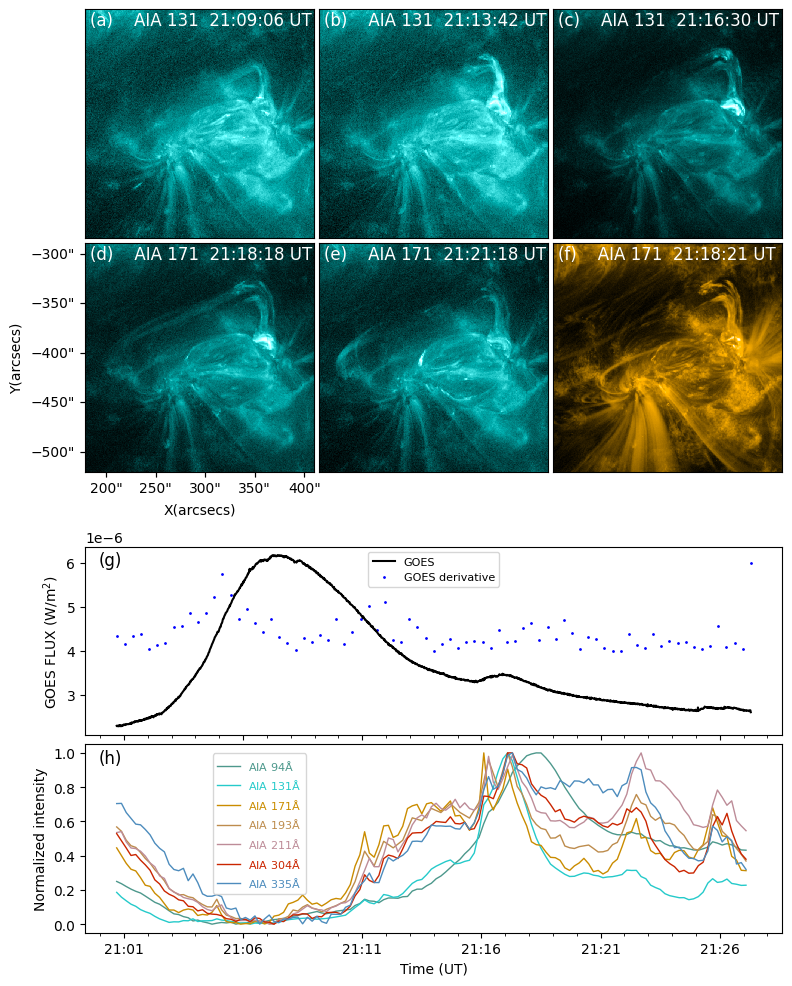

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(9,12))

# 整体划分为上下两大块：上(3份高度)，下(2份高度)
gs = gridspec.GridSpec(2, 1, height_ratios=[6, 5], hspace=0.175)

# ---------------- 上半部分：AIA 三幅图 ----------------
# 这里再细分成 1 行 3 列的小网格
gs_top = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[0], wspace=0.02,hspace=0.02)
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)

map_all=[map1,map2,map3,map4,map5,map6]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

ax_all=[]
for i in range(6):
    ax=fig.add_subplot(gs_top[i],projection=smap_all[i])
    ax_all.append(ax)
    smap_all[i].plot(axes=ax)
    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第四张图加X Y轴
    if i == 3:   # 左下角
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X(arcsecs)')
        ax.set_ylabel('Y(arcsecs)')
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)       
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

ax_all[0].text(0.02,0.93,'(a)    AIA 131  21:09:06 UT',color='white',transform=ax_all[0].transAxes,fontsize=12)
ax_all[1].text(0.02,0.93,'(b)    AIA 131  21:13:42 UT',color='white',transform=ax_all[1].transAxes,fontsize=12)
ax_all[2].text(0.02,0.93,'(c)    AIA 131  21:16:30 UT',color='white',transform=ax_all[2].transAxes,fontsize=12)
ax_all[3].text(0.02,0.93,'(d)    AIA 171  21:18:18 UT',color='white',transform=ax_all[3].transAxes,fontsize=12)
ax_all[4].text(0.02,0.93,'(e)    AIA 171  21:21:18 UT',color='white',transform=ax_all[4].transAxes,fontsize=12)
ax_all[5].text(0.02,0.93,'(f)    AIA 171  21:18:21 UT',color='white',transform=ax_all[5].transAxes,fontsize=12)

# ---------------- 下半部分：两行共享x轴 ----------------
gs_bottom = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1], hspace=0.05)

ax8 = fig.add_subplot(gs_bottom[1])
ax7 = fig.add_subplot(gs_bottom[0],sharex=ax8)


from scipy.interpolate import splprep, splev
from scipy.ndimage import zoom
corr_x=np.zeros(6)
#第一个时刻对应21：00：42，最后一个时刻对应21：27：06
for i in range(len(corr_x)):
    corr_x[i]=(i*300+18)/12

#y为GOES值
goes_x=np.linspace(0,133,1585)
goes_y=ff.variables['irradiance_xrsb1'][75642:75642+1585]
#求导，缩并
dy_dx=np.gradient(goes_y,goes_x)
dy_dx_reduced=zoom(dy_dx,0.05)

ax7.plot(goes_x,goes_y,color='black',label='GOES')
der_goes=abs(dy_dx_reduced)
der_goes2=(der_goes-np.min(der_goes))/(np.max(der_goes)-np.min(der_goes))
ax7.scatter(np.linspace(0,133,len(dy_dx_reduced)),(der_goes2+2)*1e-6*2,color='blue',s=1,label='GOES derivative')
ax7.set_ylabel('GOES FLUX (W/m$^2$)')
ax7.text(0.02,0.90,'(g)',color='black',transform=ax7.transAxes,fontsize=12)
handles1, labels1 = ax7.get_legend_handles_labels()
ax7.legend(handles1, labels1, loc='upper center',fontsize=8)
ax7.tick_params(labelbottom=False)

name_list=['AIA 94$\mathrm{\AA}$','AIA 131$\mathrm{\AA}$',
           'AIA 171$\mathrm{\AA}$','AIA 193$\mathrm{\AA}$',
           'AIA 211$\mathrm{\AA}$','AIA 304$\mathrm{\AA}$','AIA 335$\mathrm{\AA}$']
lines=[]
linstyle=['-','-']

#从AIA那几个波段的cmap里采集颜色用来画曲线
color=[]
color_list=['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335']
for i in range(7):
    cmap=plt.get_cmap(color_list[i])
    middle_color=cmap(0.55)
    color.append(middle_color)

for i in range(7):
    line,=ax8.plot(intensity[i,:],color=color[i],label=name_list[i],linewidth=1,linestyle=linstyle[i%2])
    lines.append(line)
legend=ax8.legend(loc='center', bbox_to_anchor=(0.25, 0.58),fontsize=8)
for text,line in zip(legend.get_texts(),lines):
    text.set_color(line.get_color())

ax8.set_ylabel('Normalized intensity')
ax8.set_xticks(ticks=corr_x,labels=['21:01','21:06','21:11','21:16','21:21','21:26'])
ax8.text(0.02,0.9,'(h)',color='black',transform=ax8.transAxes,fontsize=12)
import matplotlib.ticker as ticker
ax8.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax8.yaxis.set_minor_locator(ticker.NullLocator())       # 禁止 y 轴小刻度
ax8.set_xlabel('Time (UT)')
plt.savefig(r'D:\Learning\PHD1st\magnetic_reconnecion\paper\fig\aia_image_intensity_goes_curve.pdf',format='pdf')